In [49]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Metadata 

In [3]:
metadata_dictionary = pd.read_csv('metadata_dictionary.csv')
metadata_dictionary.head()

,Variable,Description
0,patient_id,An identifier for the subject
1,diagnosis,The diagnosis of the subject
2,sudden_death,Whether the subject has had a sudden death or not
3,basal_pattern,Whether the baseline ECG is pathological or not
4,brugada,The diagnosis of the subject


| Variabel | Deskripsi |
|----|---- |
| patient_id | Pengidentifikasi unik untuk setiap pasien |
| diagnosis | Diagnosis untuk pasien | 
| sudden_death | Apakah pasien mengalami kematian mendadak | 
| basal_pattern | Apakah EKG menunjukkan pola Brugada |
| Brugada | Pasien didiagnosis sindrom brugada | 


## Loading the Dataset 

### Reading Metadata

In [4]:
metadata = pd.read_csv('metadata.csv')
metadata.head()

,patient_id,basal_pattern,sudden_death,brugada
0,188981,1,0,1
1,251972,0,0,0
2,265715,0,0,0
3,267628,0,0,0
4,267630,0,0,1


In [5]:
print(f"Total subjects: {len(metadata)}")
print(f"Brugada patients: {(metadata['brugada'] > 0).sum()}")
print(f"Healthy subjects: {(metadata['brugada'] == 0).sum()}")

Total subjects: 363
Brugada patients: 76
Healthy subjects: 287


#### Class Distribution

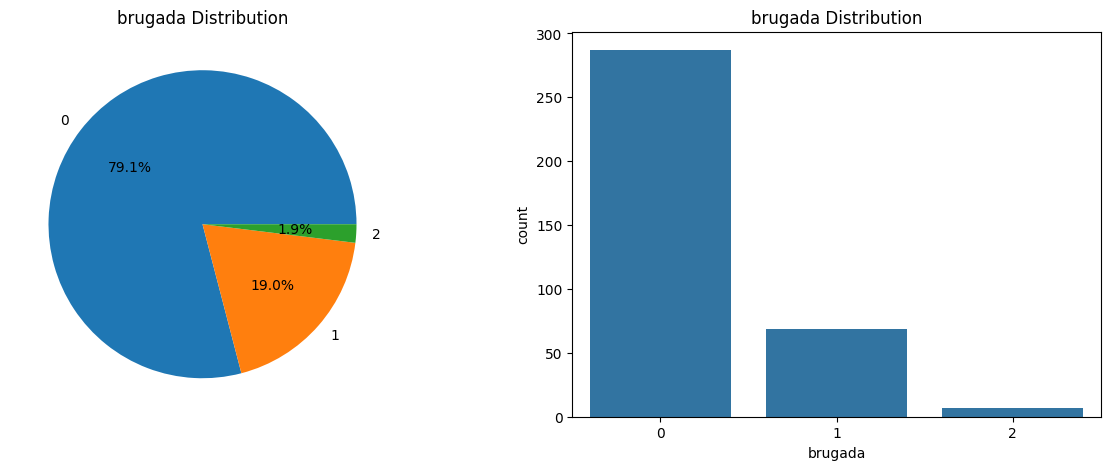

In [6]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
counts = metadata["brugada"].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("brugada Distribution")

plt.subplot(1,2,2)
sns.countplot(x=metadata["brugada"])
plt.title("brugada Distribution")
plt.show()

#### Basal Pattern Distribution

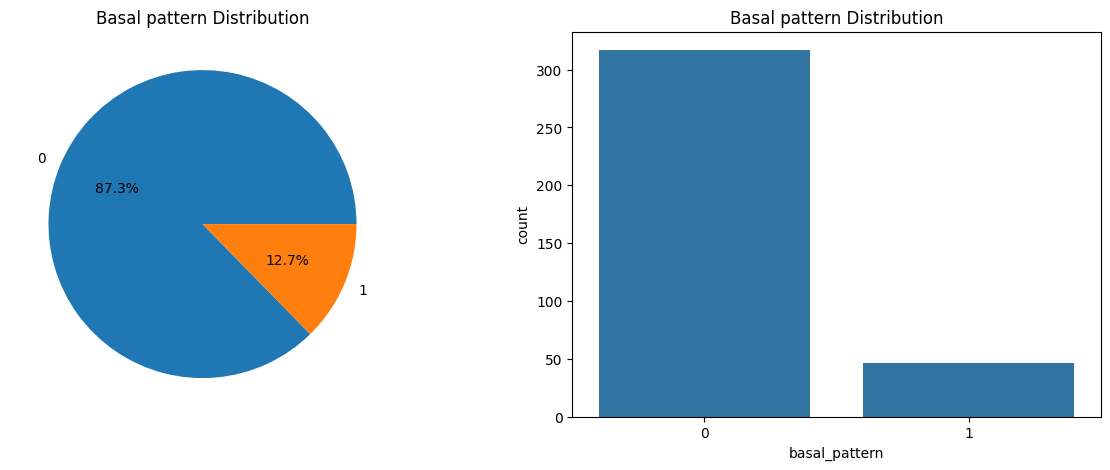

In [7]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
counts = metadata["basal_pattern"].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Basal pattern Distribution")

plt.subplot(1,2,2)
sns.countplot(x=metadata["basal_pattern"])
plt.title("Basal pattern Distribution")
plt.show()

#### Sudden Death Distribution

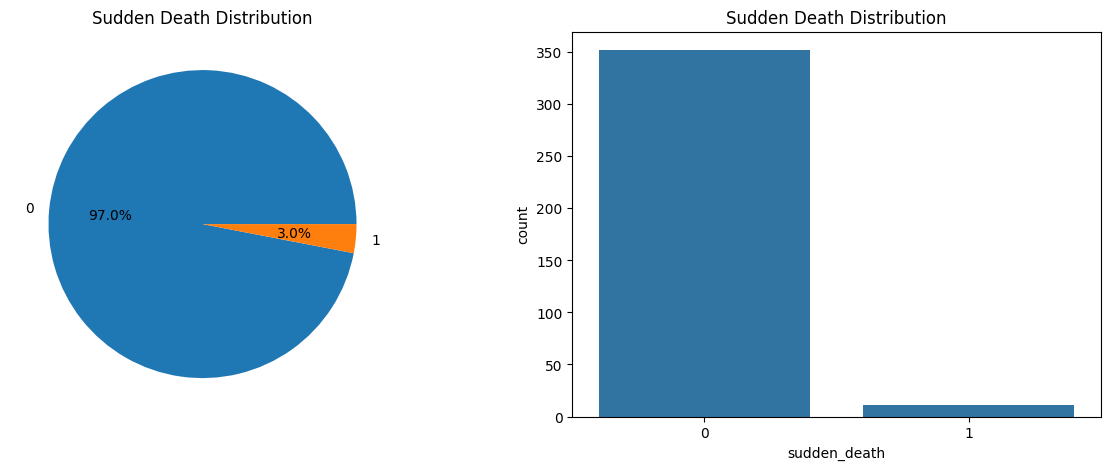

In [8]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
counts = metadata["sudden_death"].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Sudden Death Distribution")

plt.subplot(1,2,2)
sns.countplot(x=metadata["sudden_death"])
plt.title("Sudden Death Distribution")
plt.show()

### Reading ECG (Electrocardiogram) Signals


In [41]:
# patien_id with brugada type 2: 460919
# patiend_id with brugada type 1: 419960
# patiend_id normal: 251972
patient_id = '251972'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

In [42]:
signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs
duration = len(signals / sampling_freq) 

In [43]:
print(f"Sampling rate: {record.fs} Hz")
print(f"Lead names: {record.sig_name}")
print(f"Duration: {duration} seconds")
print(f"Data shape: {signals.shape}")

Sampling rate: 100 Hz
Lead names: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Duration: 1200 seconds
Data shape: (1200, 12)


#### Amplitude Distribution

In [50]:
signal = record.p_signal

print("Min amplitude:", np.min(signal))
print("Max amplitude:", np.max(signal))
print("Mean amplitude:", np.mean(signal))
print("Std amplitude:", np.std(signal))

Min amplitude: -1.592
Max amplitude: 1.78
Mean amplitude: -0.007388333333333332
Std amplitude: 0.21405894120156096


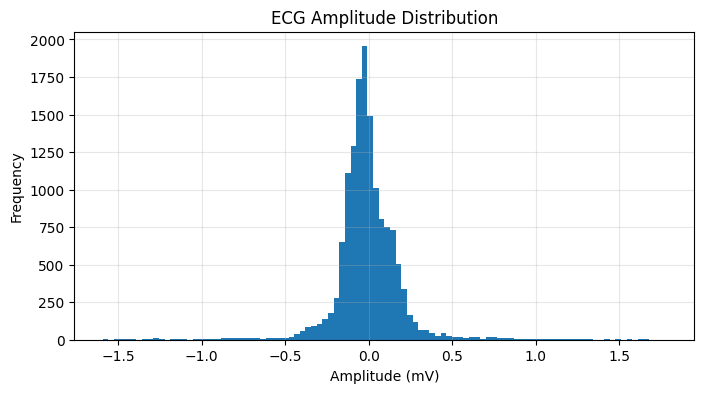

In [51]:
plt.figure(figsize=(8,4))
plt.hist(signal.flatten(), bins=100)

plt.title("ECG Amplitude Distribution")
plt.xlabel("Amplitude (mV)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.show()

In [ ]:
for i, lead in enumerate(lead_names):
  lead_signal = signal[:, i]

  print(f"{lead}")
  print("min:", np.min(lead_signal))
  print("max:", np.max(lead_signal))
  print("mean:", np.mean(lead_signal))
  print("std:", np.std(lead_signal))
  print()

I
min: -0.128
max: 0.836
mean: -0.005288333333333335
std: 0.13619253600652603

II
min: -0.457
max: 1.103
mean: -0.007426666666666663
std: 0.2277486435134625

III
min: -0.418
max: 0.402
mean: -0.00912916666666666
std: 0.1701406696902269

aVR
min: -0.937
max: 0.271
mean: -0.0038091666666666664
std: 0.1674150861859196

aVL
min: -0.206
max: 0.497
mean: -0.0031424999999999977
std: 0.10407544792320937

aVF
min: -0.418
max: 0.727
mean: -0.008139166666666664
std: 0.18927352288677946

V1
min: -1.592
max: 0.339
mean: 0.007490000000000001
std: 0.30053775675168226

V2
min: -0.885
max: 0.247
mean: -0.0064283333333333345
std: 0.1516414186951866

V3
min: -1.398
max: 1.31
mean: -0.008015833333333333
std: 0.31609731716035205

V4
min: -0.841
max: 1.78
mean: -0.008885833333333332
std: 0.29670004403882194

V5
min: -0.332
max: 1.349
mean: -0.03032333333333333
std: 0.22786435026616653

V6
min: -0.15
max: 0.894
mean: -0.005561666666666664
std: 0.14772716810804376



### Reading first lead ECG

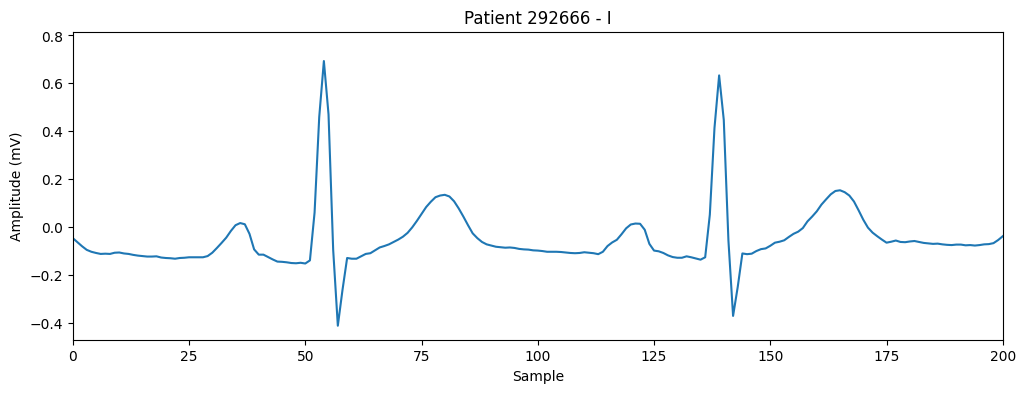

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(signals[:, 0])
plt.title(f'Patient {patient_id} - {lead_names[0]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.xlim(0, 300)
plt.show()

### Reading all leads ECG

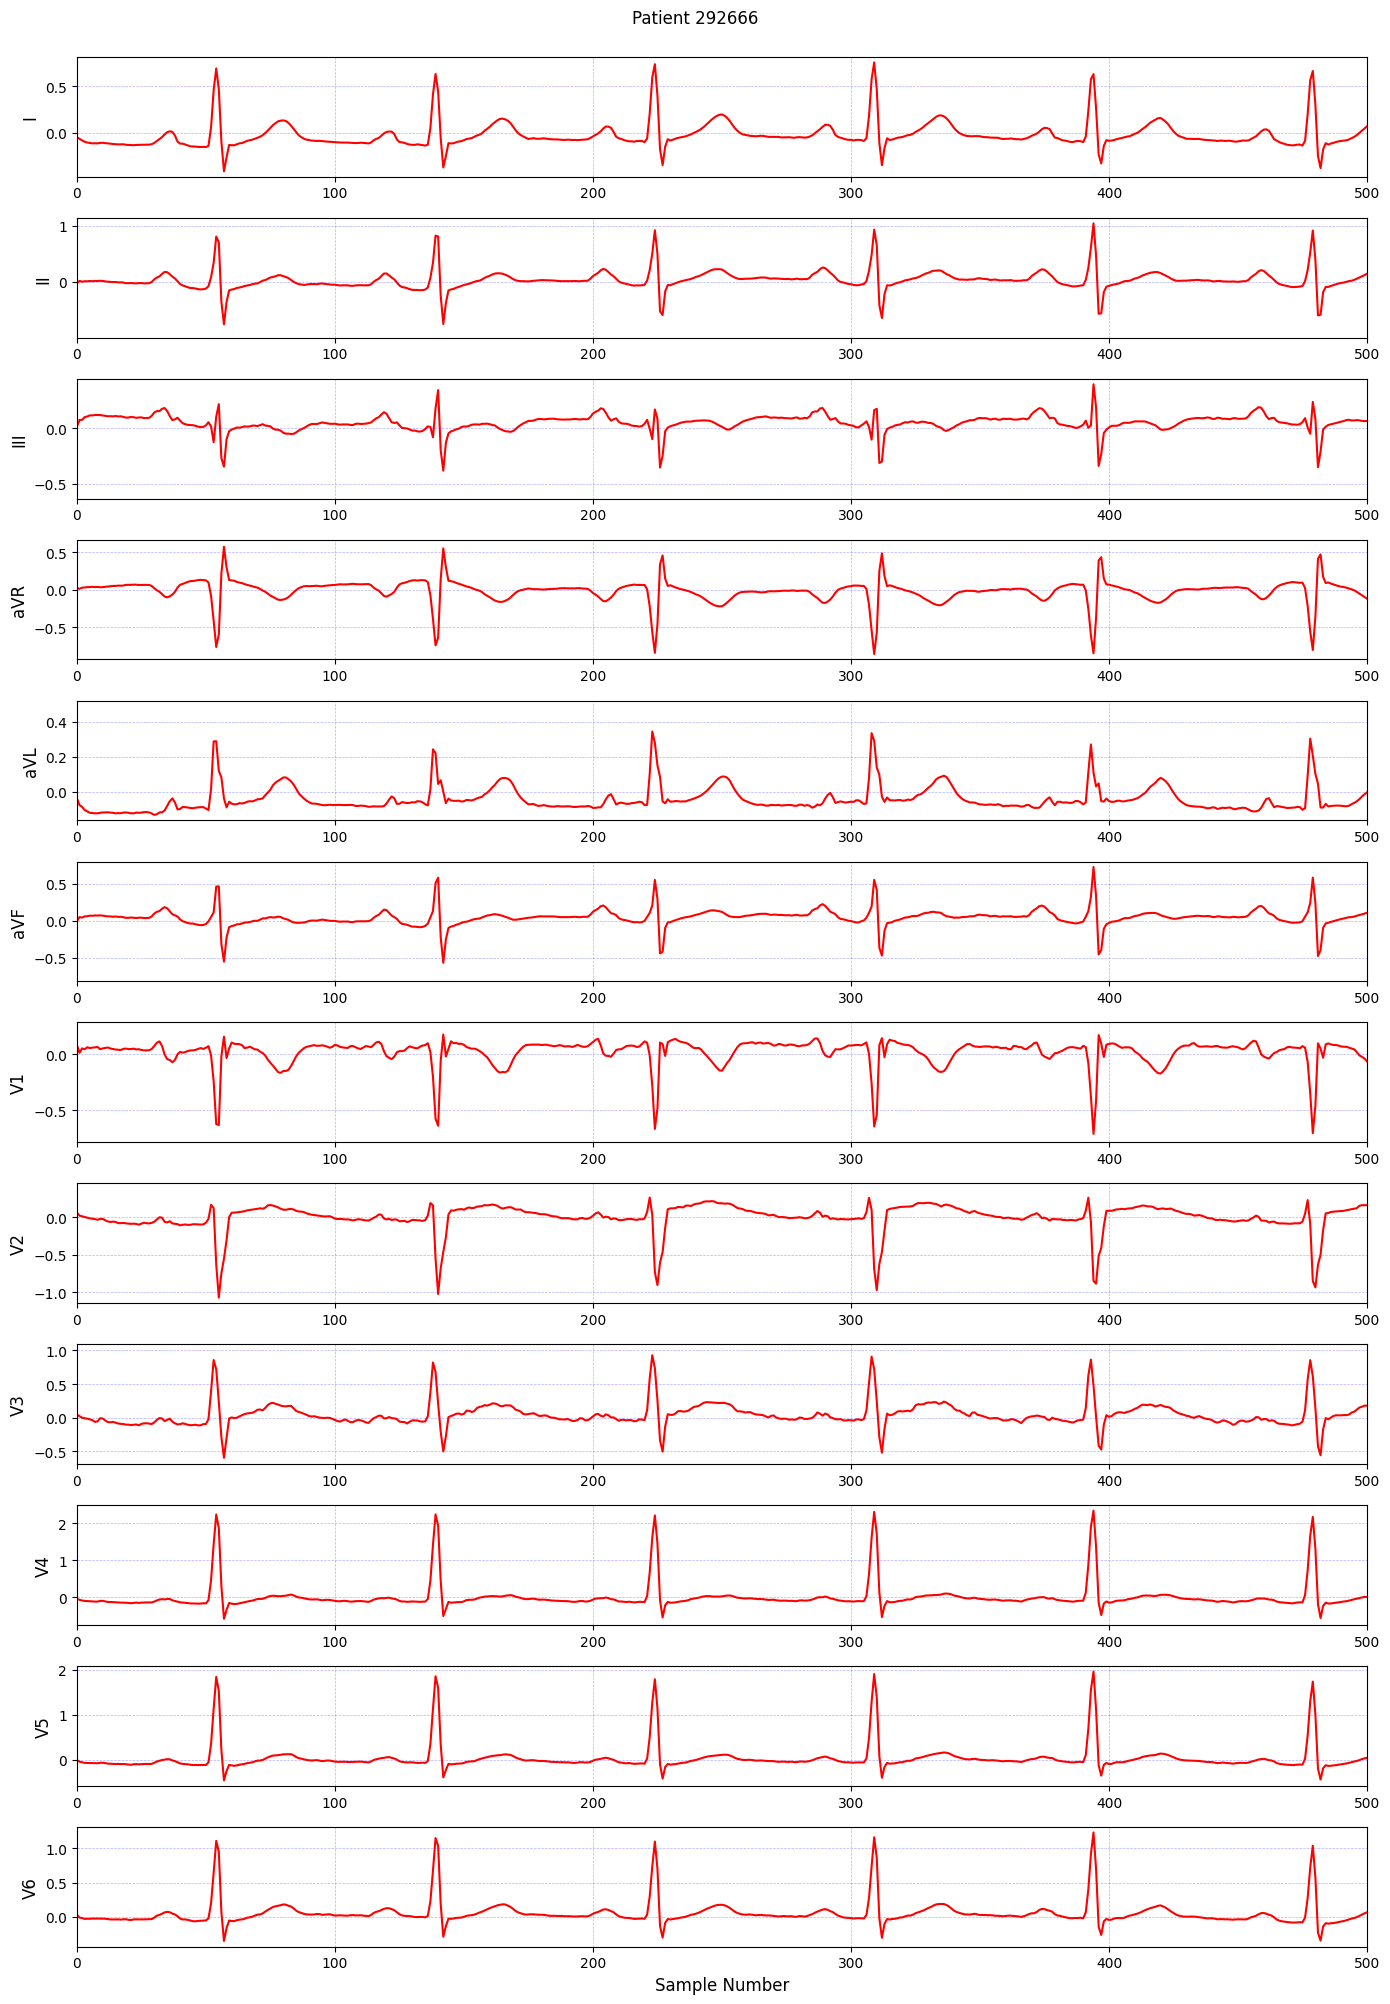

In [40]:
fig, axes = plt.subplots(12, 1, figsize=(14, 20))

for i, lead_name in enumerate(lead_names):
  axes[i].plot(signals[:, i], linewidth=1.5, color='red')
  axes[i].set_ylabel(lead_name, fontsize=12, fontweight='medium')
  axes[i].grid(True, linestyle='--', linewidth=0.5, color='blue', alpha=0.3)

  # focusing waveform at specific time (0, duration)
  axes[i].set_xlim(0, 500) 

plt.suptitle(f'Patient {patient_id}', y=1)
plt.xlabel('Sample Number', fontsize=12)
plt.tight_layout()
plt.show()

#### Normal VS Brugada ECG (Lead V1)

In [15]:
normal_patient_id = '251972'
normal_record = wfdb.rdrecord(f'files/{normal_patient_id}/{normal_patient_id}')

In [16]:
brugada_patient_id = '509648'
brugada_record = wfdb.rdrecord(f'files/{brugada_patient_id}/{brugada_patient_id}')

In [35]:
focus_indices = [6,7,8]  # V1 V2 V3
focus_leads = lead_names[6:9]

### Exploratory Data Analysis (EDA)

In [ ]:
df = pd.DataFrame(signals, columns=lead_names)
df.head()

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,-0.047,-0.025,0.015,0.027,-0.036,-0.005,0.080,0.063,0.048,-0.048,-0.008,0.030
1,-0.064,0.019,0.077,0.014,-0.075,0.048,0.011,0.025,0.023,-0.067,-0.046,-0.010
2,-0.081,0.005,0.079,0.030,-0.085,0.042,0.050,0.016,0.000,-0.086,-0.059,-0.017
3,-0.096,0.013,0.103,0.032,-0.103,0.058,0.043,0.007,-0.008,-0.097,-0.073,-0.029
4,-0.104,0.011,0.109,0.037,-0.111,0.060,0.060,-0.003,-0.014,-0.102,-0.075,-0.027


In [ ]:
df.shape

(1200, 12)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I       1200 non-null   float64
 1   II      1200 non-null   float64
 2   III     1200 non-null   float64
 3   aVR     1200 non-null   float64
 4   aVL     1200 non-null   float64
 5   aVF     1200 non-null   float64
 6   V1      1200 non-null   float64
 7   V2      1200 non-null   float64
 8   V3      1200 non-null   float64
 9   V4      1200 non-null   float64
 10  V5      1200 non-null   float64
 11  V6      1200 non-null   float64
dtypes: float64(12)
memory usage: 112.6 KB


In [ ]:
df.describe()

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,-0.030520,-0.021677,0.002266,0.017378,-0.020739,-0.009607,0.021622,0.006309,0.040366,-0.005070,0.021750,0.045957
std,0.140915,0.190580,0.105301,0.159389,0.079975,0.136988,0.121023,0.183693,0.174582,0.366028,0.292577,0.178022
min,-0.413000,-0.892000,-0.587000,-0.854000,-0.131000,-0.741000,-0.734000,-1.074000,-0.607000,-0.599000,-0.463000,-0.355000
25%,-0.101000,-0.098000,-0.034250,-0.032250,-0.074000,-0.056250,0.001750,-0.038000,-0.044000,-0.120250,-0.077000,-0.025000
50%,-0.070000,-0.025500,0.019000,0.038000,-0.047000,0.003000,0.059000,0.023000,0.010000,-0.078000,-0.040000,0.011000
75%,0.004000,0.052250,0.069000,0.091000,0.015000,0.056000,0.082000,0.113000,0.101500,-0.026000,0.021000,0.065000
max,0.757000,1.041000,0.402000,0.596000,0.488000,0.722000,0.232000,0.384000,1.011000,2.344000,1.962000,1.228000


In [ ]:
# reshape dataframe dari wide ke long format
df_melted = df.melt(var_name="lead_name", value_name="voltage")

# ----
df_melted.head(10)

,lead_name,voltage
0,I,-0.047
1,I,-0.064
2,I,-0.081
3,I,-0.096
4,I,-0.104
5,I,-0.109
6,I,-0.113
7,I,-0.112
8,I,-0.113
9,I,-0.108


In [ ]:
missing_value = df.isnull().sum()
print(missing_value)

I      0
II     0
III    0
aVR    0
aVL    0
aVF    0
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
dtype: int64


#### Outlier Detection


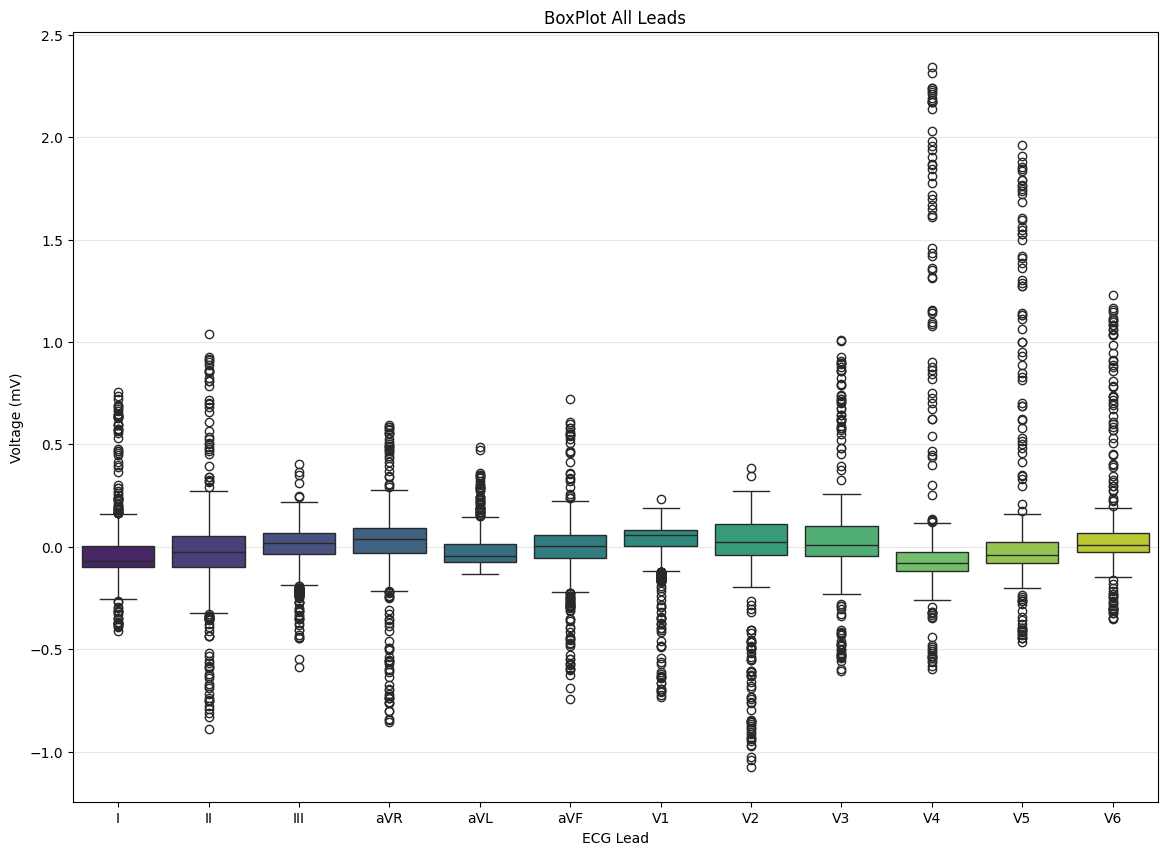

In [ ]:
plt.figure(figsize=(14, 10))
sns.boxplot(x='lead_name', y='voltage', data=df_melted, hue='lead_name', palette='viridis')
plt.title("BoxPlot All Leads")
plt.ylabel('Voltage (mV)')
plt.xlabel('ECG Lead')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
IQ1 = df.quantile(0.25)
IQ3 = df.quantile(0.75)

IQR = IQ3 - IQ1

lower_bound = IQ1 - 1.5 * IQR
upper_bound = IQ3 + 1.5 * IQR

outliers = ((df < lower_bound) | (df > upper_bound))

outliers_count = outliers.sum()
samples_per_lead = outliers.shape[0]

for lead, count in outliers_count.items():
  percentages = (count / samples_per_lead) * 100
  print(f"{lead:4s}: {count:3d} outliers ({percentages:.2f}%)")

I   :  86 outliers (7.17%)
II  :  77 outliers (6.42%)
III :  72 outliers (6.00%)
aVR :  73 outliers (6.08%)
aVL :  47 outliers (3.92%)
aVF :  78 outliers (6.50%)
V1  : 107 outliers (8.92%)
V2  :  62 outliers (5.17%)
V3  :  71 outliers (5.92%)
V4  :  87 outliers (7.25%)
V5  :  83 outliers (6.92%)
V6  :  80 outliers (6.67%)
